## Undersök Datasetet

In [28]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#Ladda in datasetet
df = pd.read_csv('Dataset/train.csv')
print("\n=== Sammanfattning av Data ===")
print(df.info())
print("\n=== Datatyper och unika värden per kolumn ===")
for col in df.columns:
    print(f"{col}: {df[col].dtype}, {df[col].nunique()} unika värden")
print("--------------------------------")
print("Dubblikater i Data:", df.duplicated().sum())
print("Missing value detection:",df.isnull().sum().sum())





=== Sammanfattning av Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB
None

=== Datatyper och unika värden per kolumn ===
date: object, 1826 unika värden
store: int64, 10 unika värden
item: int64, 50 unika värden
sales: int64, 213 unika värden
--------------------------------
Dubblikater i Data: 0
Missing value detection: 0


## Datavisualisering

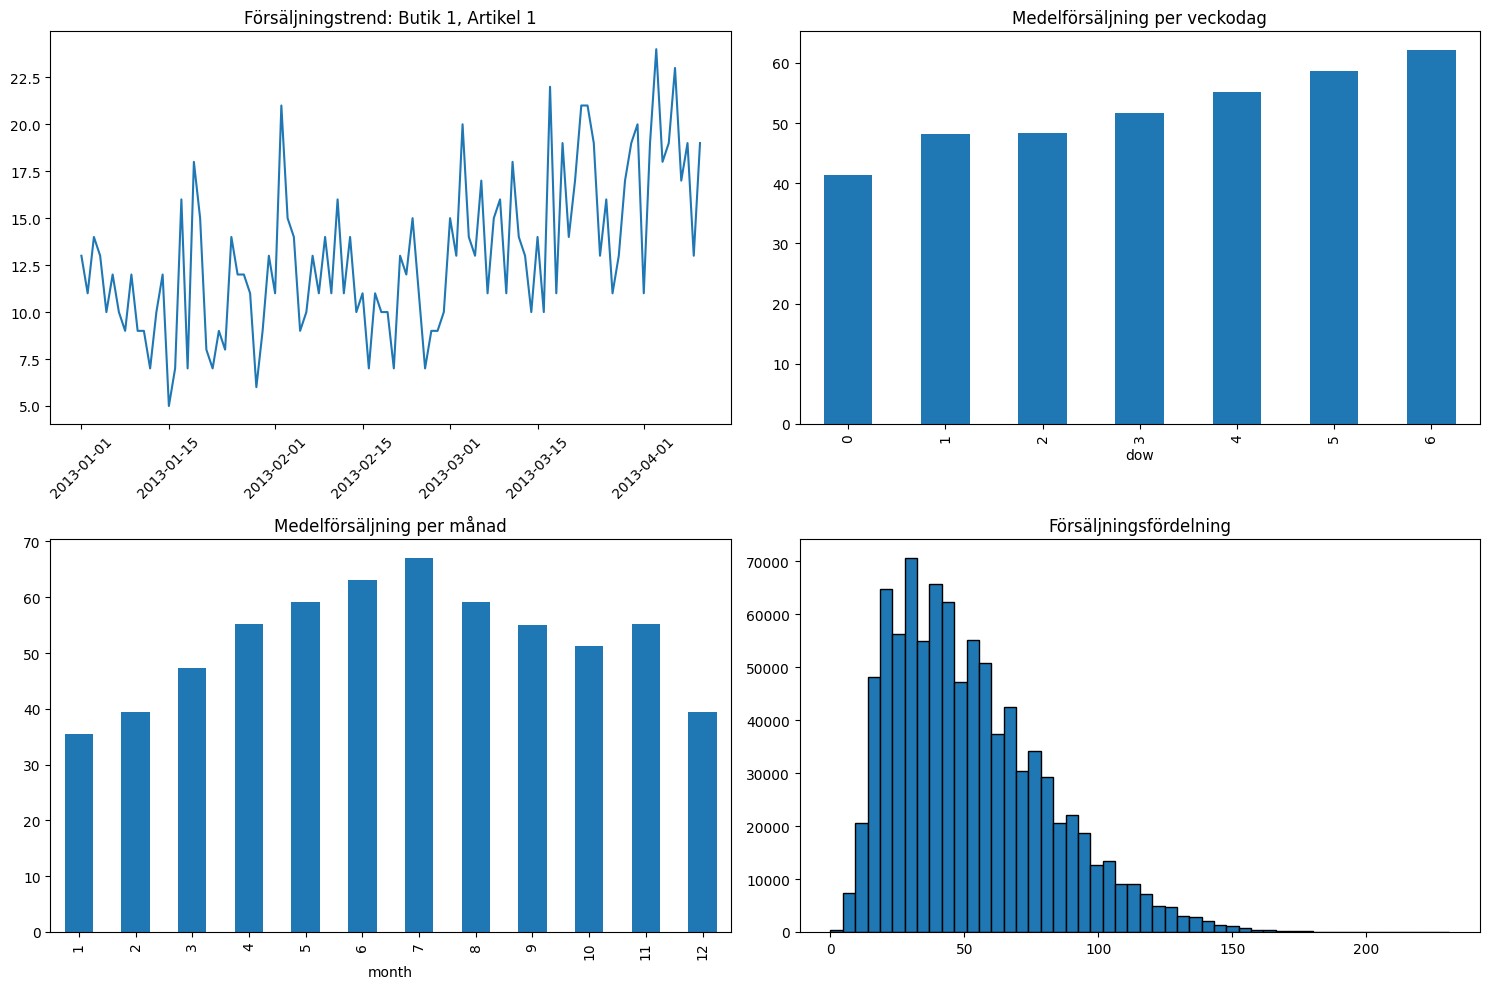

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Exempel: försäljning över tid
sample = df[(df['store'] == 1) & (df['item'] == 1)].head(100)
axes[0, 0].plot(sample['date'], sample['sales'])
axes[0, 0].set_title('Försäljningstrend: Butik 1, Artikel 1')
axes[0, 0].tick_params(axis='x', rotation=45)

# Medelvärde per veckodag
df.groupby('dow')['sales'].mean().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Medelförsäljning per veckodag')

# Medelvärde per månad
df.groupby('month')['sales'].mean().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Medelförsäljning per månad')

# Fördelning av försäljning
axes[1, 1].hist(df['sales'], bins=50, edgecolor='black')
axes[1, 1].set_title('Försäljningsfördelning')

plt.tight_layout()
plt.show()


## Hantering av dubbletter, saknade värden och typkonvertering

In [32]:
# Kör minimala datakontroller
import pandas as pd

def run_min_checks(df: pd.DataFrame, date_format: str = "%Y-%m-%d"):
    issues = {}
    # Kolumner
    required = ["date", "store", "item", "sales"]
    missing_cols = [c for c in required if c not in df.columns]
    issues["missing_columns"] = missing_cols

    # Typkonvertering (tålig) + kopia
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"], format=date_format, errors="coerce")
    d["store"] = pd.to_numeric(d["store"], errors="coerce")
    d["item"]  = pd.to_numeric(d["item"],  errors="coerce")
    d["sales"] = pd.to_numeric(d["sales"], errors="coerce")

    type_fail = {
        "date": int(d["date"].isna().sum()),
        "store": int(d["store"].isna().sum()),
        "item":  int(d["item" ].isna().sum()),
        "sales": int(d["sales"].isna().sum()),
    }
    issues["type_conversion_nulls"] = type_fail

    # Nulls (efter konvertering)
    nulls = d.isna().sum().to_dict()
    issues["nulls_per_column"] = {k:int(v) for k,v in nulls.items()}

    # Nyckelunikhet
    dup_cnt = int(d.duplicated(["date","store","item"]).sum())
    issues["key_duplicates"] = dup_cnt

    # Härled förväntad cardinalitet
    n_stores = int(d["store"].nunique())
    n_items  = int(d["item" ].nunique())
    n_dates  = int(d["date" ].nunique())
    issues["cardinality"] = {"stores": n_stores, "items": n_items, "dates": n_dates}

    # Per-dag fullständighet
    expected_per_day = n_stores * n_items
    per_day = d.groupby("date").size()
    bad_days = per_day[per_day != expected_per_day]
    issues["bad_days_count"] = int(bad_days.size)
    issues["bad_days_examples"] = [str(idx.date()) for idx in bad_days.index[:5]]

    # Volym sanity
    total_expected = expected_per_day * n_dates
    issues["total_rows"] = int(len(d))
    issues["total_expected"] = int(total_expected)
    issues["total_match"] = (len(d) == total_expected)

    # Sales rimlighet
    nonneg_fail = int((d["sales"] < 0).sum())
    upper = float(d["sales"].quantile(0.999) * 1.5)
    outliers_high = int((d["sales"] > upper).sum())
    issues["sales_checks"] = {
        "nonneg_fail": nonneg_fail,
        "upper_bound": upper,
        "outliers_high": outliers_high,
    }

    # Print sammanfattning
    print("=== Minimal Data Quality Checks ===")
    print("Missing columns:", issues["missing_columns"])
    print("Type conversion nulls:", issues["type_conversion_nulls"])
    print("Nulls per column:", issues["nulls_per_column"])
    print("Key duplicates:", issues["key_duplicates"])
    print("Cardinality:", issues["cardinality"])
    print(f"Per-day expected {expected_per_day}, bad days:", issues["bad_days_count"])
    print("Bad day examples:", issues["bad_days_examples"])
    print("Total rows:", issues["total_rows"], "| Total expected:", issues["total_expected"], "| Match:", issues["total_match"])
    print("Sales checks:", issues["sales_checks"])
    return issues

checks = run_min_checks(df, date_format="%Y-%m-%d")

=== Minimal Data Quality Checks ===
Missing columns: []
Type conversion nulls: {'date': 0, 'store': 0, 'item': 0, 'sales': 0}
Nulls per column: {'date': 0, 'store': 0, 'item': 0, 'sales': 0}
Key duplicates: 0
Cardinality: {'stores': 10, 'items': 50, 'dates': 1826}
Per-day expected 500, bad days: 0
Bad day examples: []
Total rows: 913000 | Total expected: 913000 | Match: True
Sales checks: {'nonneg_fail': 0, 'upper_bound': 246.0, 'outliers_high': 0}


## Skapa nya features

Koden läser in en träningsdataset från en CSV-fil och skapar nya “features” (variabler) som kan användas i t.ex. en maskininlärningsmodell för att förutsäga **sales**. Den gör främst tre saker:

1. **Förbereder datumkolumnen** (tolkar datum, sorterar per butik/produkt och tid).
2. **Skapar datum-baserade features** (veckodag, månad, helg, osv) + cykliska representationer (sin/cos).
3. **Skapar historik-features** för försäljning per `(store, item)`:

   * “gårdagens försäljning” (lag 1)
   * rullande medelvärde över de senaste 7 dagarna (utan dataläckage)


In [8]:
import numpy as np
import pandas as pd

# Ladda in datasetet
df = pd.read_csv("Dataset/train.csv")

# Datum-baserade features
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="coerce")
df = df.sort_values(["store", "item", "date"]).reset_index(drop=True)

df["dow"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["quarter"] = df["date"].dt.quarter
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

df["is_weekend"] = (df["dow"] >= 5).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

# Gör tid cyklisk istället för linjär (viktigt för ML-modeller)
# t.ex. att söndag och måndag samt december och januari ligger nära varandra i tid
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)


# Lag-feature: gårdagens försäljning per (store, item)
df["sales_lag_1"] = df.groupby(["store", "item"])["sales"].shift(1)

# Rullande medel 7 dagar bakåt per (store, item) utan läckage
'''
Här byggs ett 7-dagars rullande medelvärde per (store, item):
    - Viktigt: man gör först shift(1) → då används bara historiska dagar, inte dagens sales.
    - Det undviker dataläckage (att feature råkar använda information från framtiden/nutid som modellen inte skulle ha vid prediktion).
    - rolling(window=7) tar snitt över de senaste 7 observationerna (bakåt i tiden).
    - min_periods=1 gör att den kan beräkna snitt även tidigt i serien (med färre än 7 dagar).
'''

sales_shifted = df.groupby(["store", "item"], observed=True)["sales"].shift(1)
roll_mean_7 = (
    sales_shifted
    .groupby([df["store"], df["item"]], observed=True)
    .rolling(window=7, min_periods=1)
    .mean()
    .reset_index(level=[0, 1], drop=True)
 )
df["roll_mean_7"] = roll_mean_7

created_cols = [
    "dow","month","day","quarter","weekofyear","is_weekend","is_month_start","is_month_end",
    "dow_sin","dow_cos","month_sin","month_cos",
    "sales_lag_1"
]
print("Feature columns created:", created_cols)

df.head()


Feature columns created: ['dow', 'month', 'day', 'quarter', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'sales_lag_1']


,date,store,item,sales,dow,month,day,quarter,weekofyear,is_weekend,is_month_start,is_month_end,dow_sin,dow_cos,month_sin,month_cos,sales_lag_1,roll_mean_7
0,2013-01-01,1,1,13,1,1,1,1,1,0,1,0,0.781831,0.623490,0.5,0.866025,NaN,NaN
1,2013-01-02,1,1,11,2,1,2,1,1,0,0,0,0.974928,-0.222521,0.5,0.866025,13.0,13.000000
2,2013-01-03,1,1,14,3,1,3,1,1,0,0,0,0.433884,-0.900969,0.5,0.866025,11.0,12.000000
3,2013-01-04,1,1,13,4,1,4,1,1,0,0,0,-0.433884,-0.900969,0.5,0.866025,14.0,12.666667
4,2013-01-05,1,1,10,5,1,5,1,1,1,0,0,-0.974928,-0.222521,0.5,0.866025,13.0,12.750000
